In [3]:
from matplotlib import pyplot as plt
from openpmd_viewer import OpenPMDTimeSeries
import sys
import numpy as np

partIn = "/pscratch/sd/a/alisa25g/ilc/diags/particles_in"
ts = OpenPMDTimeSeries(partIn)

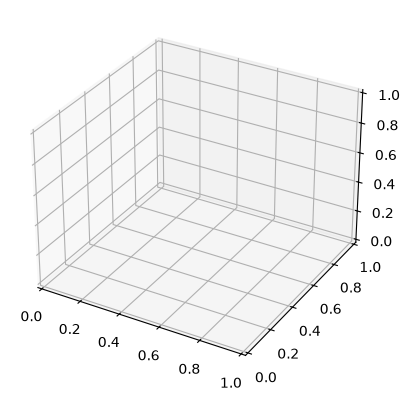

finished 0 iterations
finished 1 iterations
finished 2 iterations
finished 3 iterations
finished 4 iterations
finished 5 iterations
finished 6 iterations
finished 7 iterations
finished 8 iterations
finished 9 iterations
finished 10 iterations
finished 11 iterations
finished 12 iterations
finished 13 iterations
finished 14 iterations
finished 15 iterations
finished 16 iterations
finished 17 iterations
finished 18 iterations
finished 19 iterations
finished 20 iterations
finished 21 iterations
finished 22 iterations
finished 23 iterations
finished 24 iterations
finished 25 iterations
finished 26 iterations
finished 27 iterations
finished 28 iterations
finished 29 iterations
finished 30 iterations
finished 31 iterations
finished 32 iterations
finished 33 iterations
finished 34 iterations
finished 35 iterations
finished 36 iterations
finished 37 iterations
finished 38 iterations
finished 39 iterations
finished 40 iterations
finished 41 iterations
finished 42 iterations
finished 43 iteration

KeyboardInterrupt: 

In [4]:


#ts = OpenPMDTimeSeries(sys.argv[1])

n_particles = 10
newiters = np.array(ts.iterations)[np.linspace(0, len(ts.iterations)-1, 100, dtype=np.int32)]
n_iters = newiters.shape[0]

data1 = np.empty(shape=(n_iters, n_particles, 3))
data2 = np.empty(shape=(n_iters, n_particles, 3))

def tonumpy(pmddata, datsize=None):
    if datsize is None:
        datsize = len(pmddata[0])
    unfiltered = np.array(pmddata).T
    idxs = np.linspace(0, len(pmddata[0])-1, datsize, dtype=np.int32)
    return unfiltered[idxs]

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot([], [], [])
plt.ion()
plt.show()
plt.pause(0.1)

for i in range(n_iters):
    beam1 = tonumpy(ts.get_particle(species='beam1', var_list=['x', 'y', 'z'], iteration=newiters[i]), datsize=n_particles)
    beam2 = tonumpy(ts.get_particle(species='beam2', var_list=['x', 'y', 'z'], iteration=newiters[i]), datsize=n_particles)
    data1[i] = beam1
    data2[i] = beam2
    ax.clear()
    ax.scatter(beam1[:, 0], beam1[:, 1], beam1[:, 2], c='blue', s=10)
    ax.scatter(beam2[:, 0], beam2[:, 1], beam2[:, 2], c='red', s=10)
    if i > 1:
        for j in range(n_particles):
            for data in (data1, data2):
                trace = data[:i, j, :]
                ax.plot(trace[:, 0], trace[:, 1], trace[:, 2], 'black')
    fig.canvas.draw_idle()
    plt.pause(0.1)
    print(f'finished {i} iterations')

#ax.clear()
points = data1[:, 1, :]
#ax.plot(points[:, 0], points[:, 1], points[:, 2])

plt.close('all')
plt.plot(np.arange(points.shape[0]), points[:, 0])

plt.show()


In [12]:
%run id_track.py /pscratch/sd/a/alisa25g/ilc/diags/particles_in

finished 0 iterations
finished 1 iterations
finished 2 iterations
finished 3 iterations
finished 4 iterations
finished 5 iterations
finished 6 iterations
finished 7 iterations
finished 8 iterations
finished 9 iterations
finished 10 iterations
finished 11 iterations
finished 12 iterations
finished 13 iterations
finished 14 iterations
finished 15 iterations
finished 16 iterations
finished 17 iterations
finished 18 iterations
finished 19 iterations
finished 20 iterations
finished 21 iterations
finished 22 iterations
finished 23 iterations
finished 24 iterations
finished 25 iterations
finished 26 iterations
finished 27 iterations
finished 28 iterations
finished 29 iterations
finished 30 iterations
finished 31 iterations
finished 32 iterations
finished 33 iterations
finished 34 iterations
finished 35 iterations
finished 36 iterations
finished 37 iterations
finished 38 iterations
finished 39 iterations
finished 40 iterations
finished 41 iterations
finished 42 iterations
finished 43 iteration

ModuleNotFoundError: No module named 'cv2'

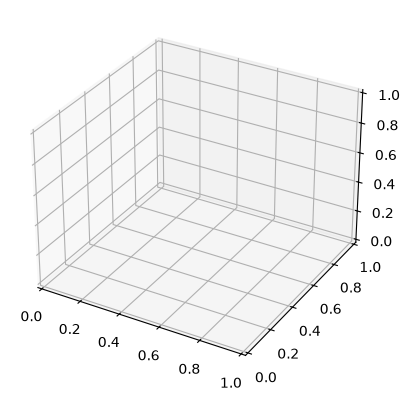

OpenPMDException: The argument `species` is missing or erroneous.
The available species are: 
 - beam1
 - beam2
 - ele_bh
 - ele_bw
 - ele_ll
 - pho1
 - pho2
 - pho_bhabha
 - pos_bh
 - pos_bw
 - pos_ll
Please set the argument `species` accordingly.

In [11]:
%run test_particle_traces.py /pscratch/sd/a/alisa25g/ilc/diags/particles_in #load particles_in_cache